In [ ]:
# This Python 3 environment comes with many helpful analytics libraries installed
# It is defined by the kaggle/python Docker image: https://github.com/kaggle/docker-python
# For example, here's several helpful packages to load

import numpy as np # linear algebra
import pandas as pd # data processing, CSV file I/O (e.g. pd. read_csv)

import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier
from sklearn.metrics import roc_auc_score, accuracy_score

import xgboost as xgb
import lightgbm as lgb

In [ ]:
# Input data files are available in the read-only "../input/" directory
# For example, running this (by clicking run or pressing Shift+Enter) will list all files under the input directory

import os
for dirname, _, filenames in os.walk('/kaggle/input'):
    for filename in filenames:
        print(os.path.join(dirname, filename))

In [ ]:

print("PURCHASE INTENT PREDICTION - DUAL OUTPUT PIPELINE")
print("=" * 60)
print("This pipeline creates two submission files:")
print("1. submission_probability.csv - Probability predictions (0-1)")
print("2. submission_binary.csv - Binary predictions (0 or 1)")
print("=" * 60)

In [ ]:
# Load data
print("\nStep 1: Loading datasets...")
train_df = pd.read_excel('kaggle/Training_Dataset.xlsx')
test_df = pd.read_excel('kaggle/Testing_Dateset.xlsx')
sample_submission = pd.read_excel('kaggle/sample_Submission.xlsx')

print(f"Training data shape: {train_df.shape}")
print(f"Test data shape: {test_df.shape}")
print(f"Sample submission shape: {sample_submission.shape}")

### Visualizations Before Data Processing

In [ ]:
import seaborn as sns
import matplotlib.pyplot as plt

# Set up a grid for multiple plots
fig, axes = plt.subplots(2, 3, figsize=(22, 12))
fig.suptitle("Test Data - Visualizations Before Processing", fontsize=18, y=1.03)

# 1. Distribution of Estimated Win Rate (raw)
sns.histplot(test_df['Estimated Win Rate'], bins=30, kde=True, ax=axes[0, 0], color='skyblue')
axes[0, 0].set_title('Estimated Win Rate Distribution')
axes[0, 0].set_xlabel('Estimated Win Rate')

# 2. Distribution of Price (raw)
sns.histplot(test_df['Price'], bins=30, kde=True, ax=axes[0, 1], color='orange')
axes[0, 1].set_title('Price Distribution (raw)')
axes[0, 1].set_xlabel('Price')

# 3. Distribution of Unit Number (raw, fillna with 0 for display)
sns.histplot(test_df['Unit Number'].fillna(0), bins=20, kde=True, ax=axes[0, 2], color='teal')
axes[0, 2].set_title('Unit Number Distribution')
axes[0, 2].set_xlabel('Unit Number')

# 4. Top 10 Countries
top_countries = test_df['Country'].value_counts().head(10)
sns.barplot(x=top_countries.values, y=top_countries.index, ax=axes[1, 0], palette='viridis')
axes[1, 0].set_title('Top 10 Countries')
axes[1, 0].set_xlabel('Count')

# 5. Start Date Distribution (by year)
years = test_df['Start Date'].dt.year
sns.countplot(y=years, order=years.value_counts().index, ax=axes[1, 1], palette='Blues_r')
axes[1, 1].set_title('Start Date Distribution by Year')
axes[1, 1].set_xlabel('Count')
axes[1, 1].set_ylabel('Year')

#
missing = test_df.isnull().mean().sort_values(ascending=False).head(15)
sns.barplot(x=missing.values, y=missing.index, ax=axes[1, 2], color='red')
axes[1, 2].set_title('Top 15 Missing Value Ratios')
axes[1, 2].set_xlabel('Fraction Missing')

# Make sure Start Date is datetime
train_df['Start Date'] = pd.to_datetime(train_df['Start Date'], errors='coerce')

plt.figure(figsize=(10,5))
train_df['Start Date'].hist(bins=30)  # adjust bins for more/less granularity
plt.title("Distribution of Start Dates")
plt.xlabel("Start Date")
plt.ylabel("Frequency")
plt.xticks(rotation=45)
plt.show()

plt.tight_layout(rect=[0, 0, 1, 0.97])
plt.show()

### PreProcessing the Data

In [ ]:
print("\nStep 2: Preprocessing data...")
print(train_df.head())

In [ ]:
print(train_df.columns.values)
print("=" * 60)
print(test_df.columns.values)

In [ ]:
train_df.info() 
test_df.info()

In [ ]:
train_df.describe()

In [ ]:
train_df.describe(include=['O'])

### STEP 1: DATA CLEAN UP & FILLING MISSING VALUES

In [ ]:
# Preprocessing: handle missing values and basic cleaning

# For train_df
train_df_clean = train_df.copy()
# Fill missing Estimated Win Rate with median
train_df_clean['Estimated Win Rate'] = train_df_clean['Estimated Win Rate'].fillna(train_df_clean['Estimated Win Rate'].median())
# Fill missing Price with median
train_df_clean['Price'] = train_df_clean['Price'].fillna(train_df_clean['Price'].median())
# Fill missing Unit Number with 0
train_df_clean['Unit Number'] = train_df_clean['Unit Number'].fillna(0)
# Fill missing categorical columns with 'missing'
for col in train_df_clean.select_dtypes(include=['object']).columns:
    train_df_clean[col] = train_df_clean[col].fillna('missing')

# For test_df
test_df_clean = test_df.copy()
test_df_clean['Estimated Win Rate'] = test_df_clean['Estimated Win Rate'].fillna(test_df_clean['Estimated Win Rate'].median())
test_df_clean['Price'] = test_df_clean['Price'].fillna(test_df_clean['Price'].median())
test_df_clean['Unit Number'] = test_df_clean['Unit Number'].fillna(0)
for col in test_df_clean.select_dtypes(include=['object']).columns:
    test_df_clean[col] = test_df_clean[col].fillna('missing')

print("Preprocessing completed. Missing values handled.")

### CHECKING IF WE STILL HAVE NULL VALUES IN OUR DATA

In [ ]:
print(train_df_clean.info())
print(test_df_clean.info())

In [ ]:
# Correct test IDs to continue from training data
test_df_clean['ID'] = range(177087, 177087 + len(test_df))
print(f"Test IDs corrected: {test_df_clean['ID'].min()} to {test_df_clean['ID'].max()}")

### BASIC INTEGRITY CHECKS

In [ ]:
print("Unique IDs:", test_df_clean['ID'].is_unique)

In [ ]:
missing_ids = set(range(test_df_clean['ID'].min(), test_df_clean['ID'].max() + 1)) - set(test_df_clean['ID'])
print("Missing IDs:", len(missing_ids))

### CHECK FOR DISTRIBUTION AND CONTINUITY

In [ ]:
expected_max = 177087 + len(test_df) - 1
print("Max ID matches expectation:", test_df['ID'].max() == expected_max)

### Extract and validate target variable

In [ ]:
# Extract and validate target variable
y = train_df['Result'].values.astype(int)
print(f"\nTarget distribution: Class 0={sum(y==0)}, Class 1={sum(y==1)}")
print(f"Class balance: {sum(y==1)/len(y)*100:.1f}% positive class")

In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

# Configure the target label here if your name differs
TARGET = "Result"

print("Shape:", train_df_clean.shape)
print("\nData Types:")
print(train_df_clean.dtypes)

# Missingness summary
miss = train_df_clean.isna().mean().sort_values(ascending=False)
print("\nMissingness ratio (top 20):")
print(miss.head(20))

# Numeric summary
num_desc = train_df_clean.select_dtypes(include=[np.number]).describe().T
print("\nDescribe (numeric):")
print(num_desc)

# Target check
if TARGET not in train_df_clean.columns:
    raise KeyError(f"Target column '{TARGET}' not found in train data. Set TARGET to your actual label name.")
print("\nTarget value counts:")
print(train_df_clean[TARGET].value_counts(dropna=False))

### Visualize the Summaries

In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from pathlib import Path

# ========= Configuration =========
DF = train_df_clean            # your dataframe
TARGET = "Result"              # change if needed
MAX_NUM_HISTS = 30             # cap to avoid hundreds of plots
MAX_CAT_PLOTS = 10             # cap categorical plots
TOP_K_CAT = 15                 # top-k categories to visualize for each categorical feature
MAX_BOX_PLOTS = 10             # cap boxplots vs target
SAVE_FIGS = False              # set True to save figures
FIG_DIR = Path("fig_overview") # where to save if SAVE_FIGS=True
# =================================

if SAVE_FIGS:
    FIG_DIR.mkdir(exist_ok=True)

# ---- Safety checks
if not isinstance(DF, pd.DataFrame):
    raise TypeError("DF must be a pandas DataFrame.")
if TARGET not in DF.columns:
    raise KeyError(f"Target column '{TARGET}' not found in DataFrame.")

# ---- Helper for optional saving
def maybe_save(title_slug: str):
    if SAVE_FIGS:
        out = FIG_DIR / f"{title_slug}.png"
        plt.savefig(out, dpi=150, bbox_inches="tight")

In [ ]:
num_cols = DF.select_dtypes(include=[np.number]).columns.tolist()
if len(num_cols) >= 2:
    corr = DF[num_cols].corr(numeric_only=True)
    plt.figure(figsize=(8, 6))
    plt.imshow(corr, aspect='auto', interpolation='nearest')
    plt.title("Correlation Heatmap (Numeric Features)")
    plt.xticks(range(len(num_cols)), num_cols, rotation=90)
    plt.yticks(range(len(num_cols)), num_cols)
    plt.colorbar()
    plt.tight_layout()
    maybe_save("correlation_heatmap")
    plt.show()


In [ ]:
train_df_clean.head()
test_df_clean.head

In [ ]:
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder

print(f"Training data shape: {train_df_clean.shape}")
print(f"Test data shape: {test_df_clean.shape}")
print(f"Sample submission shape: {sample_submission.shape}")

# Correct test IDs to continue from training data
test_df_clean['ID'] = range(177087, 177087 + len(test_df_clean))
print(f"Test IDs corrected: {test_df_clean['ID'].min()} to {test_df_clean['ID'].max()}")

# Extract and validate target variable
y = train_df_clean['Result'].values.astype(int)
print(f"\nTarget distribution: Class 0={sum(y==0)}, Class 1={sum(y==1)}")
print(f"Class balance: {sum(y==1)/len(y)*100:.1f}% positive class")

In [ ]:
# Feature engineering function with proper type hints
def engineer_features(df: pd.DataFrame) -> pd.DataFrame:
    """
    Engineer features from the raw dataframe.
    
    Args:
        df: Input dataframe with raw features
        
    Returns:
        DataFrame with engineered features
    """
    df = df.copy()
    
    # Date features
    for col in ['Start Date', 'End Date']:
        if col in df.columns:
            df[col] = pd.to_datetime(df[col], errors='coerce')
    
    # Handle Contract End Date specifically  
    if 'Contract End Date' in df.columns:
        df['End Date'] = pd.to_datetime(df['Contract End Date'], errors='coerce')
    
    # Date feature engineering
    if 'Start Date' in df.columns and 'End Date' in df.columns:
        df['Journey_Duration'] = (df['End Date'] - df['Start Date']).dt.days
        # Clip to reasonable range (0-365 days), fill NaNs with 0
        df['Journey_Duration'] = df['Journey_Duration'].fillna(0).clip(lower=0, upper=365)

        # Remove unrealistic start dates
        df.loc[df['Start Date'].dt.year < 1950, 'Start Date'] = pd.NaT
        df['Start_Year'] = df['Start Date'].dt.year.fillna(df['Start Date'].dt.year.median())

        df['Start_Month'] = df['Start Date'].dt.month.fillna(6)
        df['Start_Quarter'] = df['Start Date'].dt.quarter.fillna(2)
        df['Start_DayOfWeek'] = df['Start Date'].dt.dayofweek.fillna(3)

        df['End_Year'] = df['End Date'].dt.year.fillna(df['End Date'].dt.year.median())
        df['End_Month'] = df['End Date'].dt.month.fillna(6)
        df['End_Quarter'] = df['End Date'].dt.quarter.fillna(2)
        df['End_DayOfWeek'] = df['End Date'].dt.dayofweek.fillna(3)

        # Drop original date columns
        df = df.drop(['Start Date', 'End Date'], axis=1)
        if 'Contract End Date' in df.columns:
            df = df.drop(['Contract End Date'], axis=1)

    # Numerical features
    if 'Price' in df.columns:
        price_median = df['Price'].median()
        df['Price'] = df['Price'].fillna(price_median)
        # Normalizing price to its log equivalent
        df['Price_Log'] = np.log1p(df['Price'].clip(lower=0))
        # Square root transformation for price
        df['Price_Sqrt'] = np.sqrt(df['Price'].clip(lower=0))
    
    if 'Estimated Win Rate' in df.columns:
        df['Estimated Win Rate'] = df['Estimated Win Rate'].fillna(df['Estimated Win Rate'].median())
        df['Win_Rate_Squared'] = df['Estimated Win Rate'] ** 2
        df['Win_Rate_High'] = (df['Estimated Win Rate'] > 0.75).astype(int)
        df['Win_Rate_Low'] = (df['Estimated Win Rate'] < 0.25).astype(int)
    
    if 'Unit Number' in df.columns:
        df['Unit Number'] = df['Unit Number'].fillna(0)
        df['Unit_Log'] = np.log1p(df['Unit Number'])
        df['Has_Units'] = (df['Unit Number'] > 0).astype(int)
        df['Multiple_Units'] = (df['Unit Number'] > 1).astype(int)
    
    # Customer segments
    segment_cols = [f'Customer Segment {i}' for i in range(1, 6)]
    existing_segments = [col for col in segment_cols if col in df.columns]
    if existing_segments:
        df['Active_Segments'] = df[existing_segments].notna().sum(axis=1)
    
    # Manager features
    if 'Manager' in df.columns:
        df['Has_Manager'] = df['Manager'].notna().astype(int)
    if 'Techincal Manager' in df.columns:
        df['Has_Tech_Manager'] = df['Techincal Manager'].notna().astype(int)
    
    return df

In [ ]:
print("\nStep 2: Engineering features...")
train_featured = engineer_features(train_df_clean)
test_featured = engineer_features(test_df_clean)

train_featured.columns

### Visualizations of Engineered Features and Model Predictions

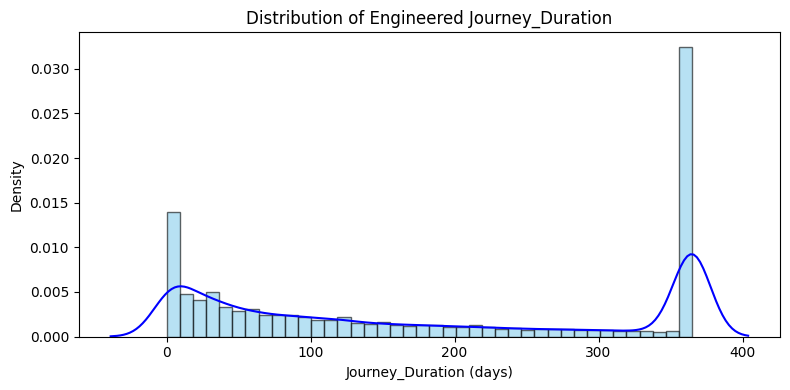

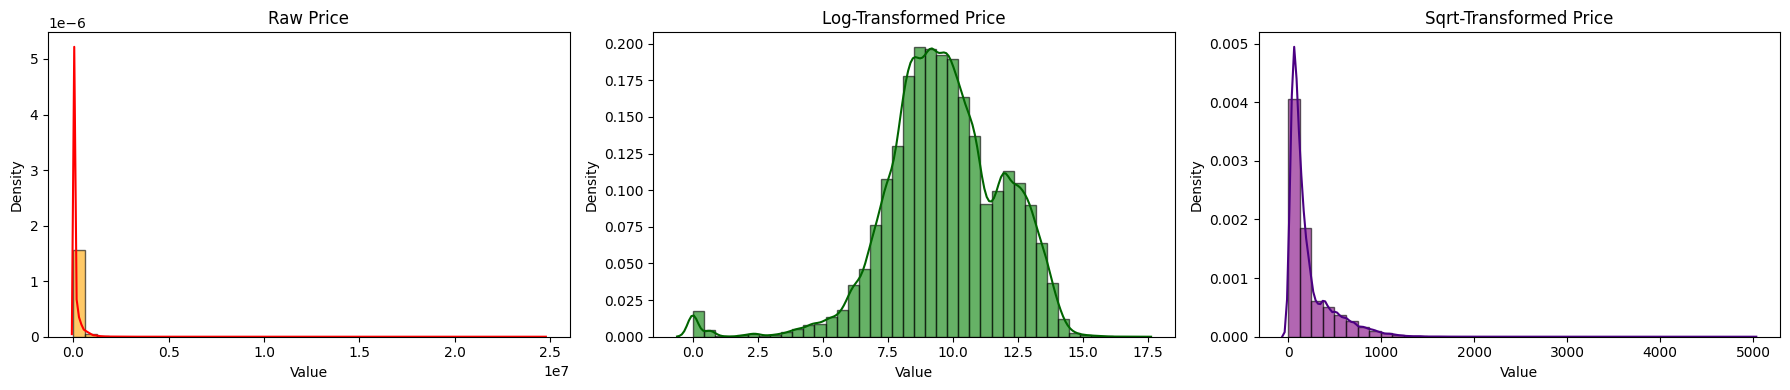

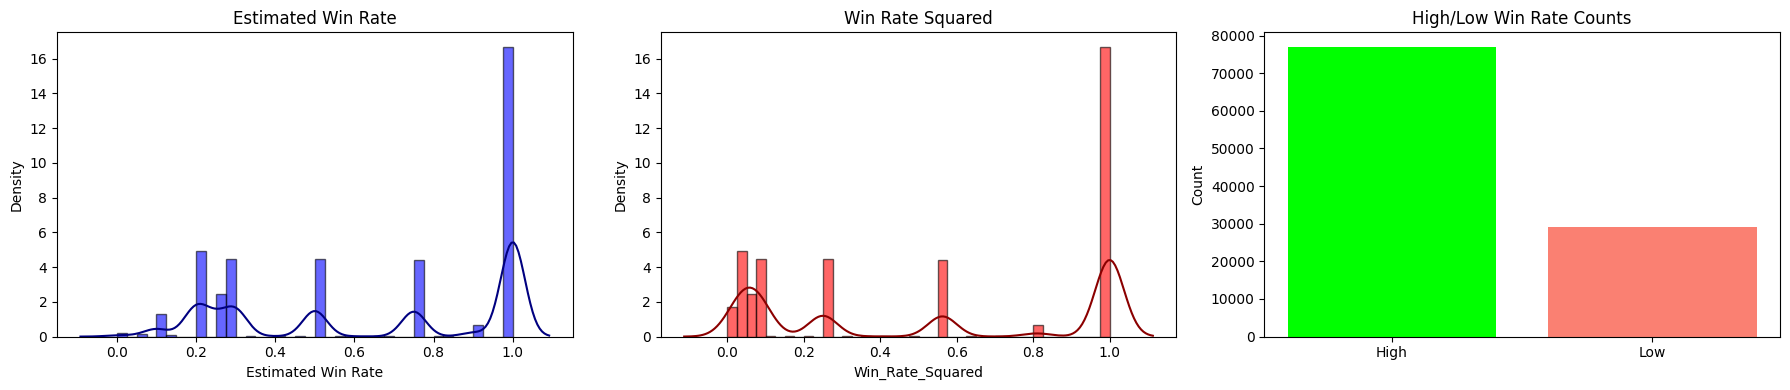

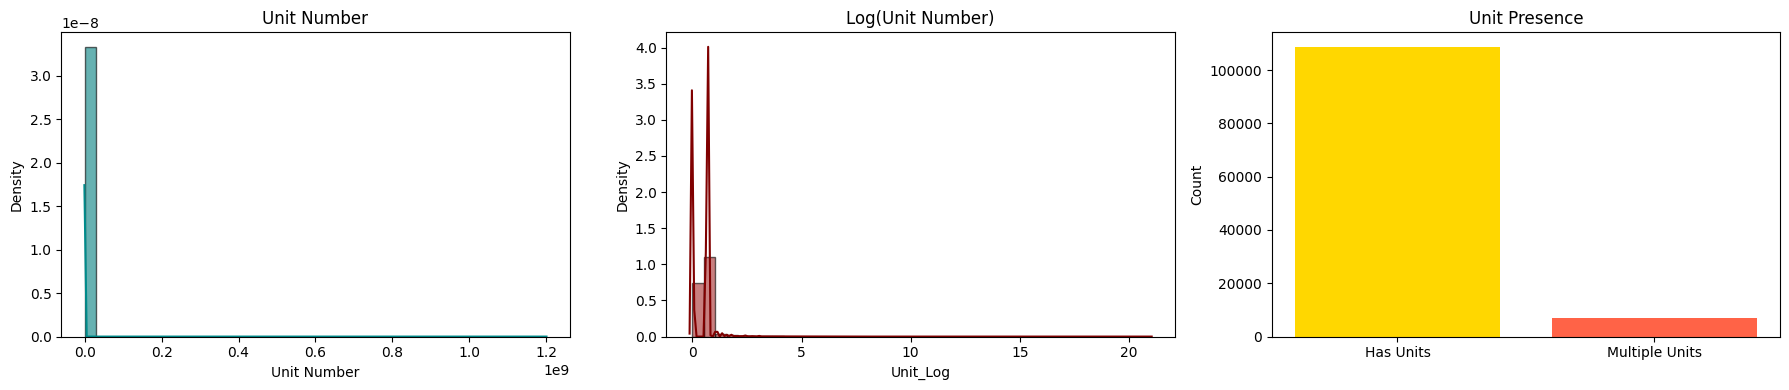

/var/folders/0j/n9gvt8712g905vzp6jvsf4nc0000gp/T/ipykernel_14460/3073927084.py:70: UserWarning: Dataset has 0 variance; skipping density estimate. Pass `warn_singular=False` to disable this warning.
  sns.kdeplot(train_featured['Active_Segments'], color='orange')


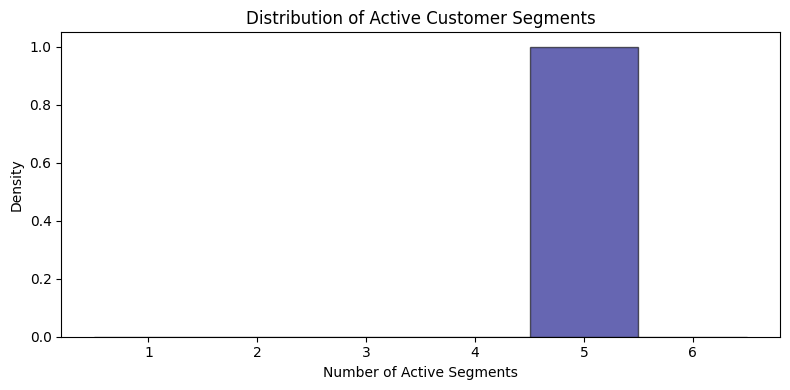

In [143]:
import matplotlib.pyplot as plt
import seaborn as sns

# 1. Journey_Duration distribution (after feature engineering)
if 'Journey_Duration' in train_featured.columns:
    plt.figure(figsize=(8,4))
    plt.hist(train_featured['Journey_Duration'], bins=40, color='skyblue', edgecolor='black', density=True, alpha=0.6)
    sns.kdeplot(train_featured['Journey_Duration'], color='blue')
    plt.title('Distribution of Engineered Journey_Duration')
    plt.xlabel('Journey_Duration (days)')
    plt.ylabel('Density')
    plt.tight_layout()
    plt.show()

# 2. Price transformations: raw, log, sqrt
fig, axes = plt.subplots(1, 3, figsize=(18, 4))
axes[0].hist(train_featured['Price'], bins=40, color='orange', edgecolor='black', density=True, alpha=0.6)
sns.kdeplot(train_featured['Price'], color='red', ax=axes[0])
axes[0].set_title('Raw Price')
axes[1].hist(train_featured['Price_Log'], bins=40, color='green', edgecolor='black', density=True, alpha=0.6)
sns.kdeplot(train_featured['Price_Log'], color='darkgreen', ax=axes[1])
axes[1].set_title('Log-Transformed Price')
axes[2].hist(train_featured['Price_Sqrt'], bins=40, color='purple', edgecolor='black', density=True, alpha=0.6)
sns.kdeplot(train_featured['Price_Sqrt'], color='indigo', ax=axes[2])
axes[2].set_title('Sqrt-Transformed Price')
for ax in axes:
    ax.set_xlabel('Value')
    ax.set_ylabel('Density')
plt.tight_layout()
plt.show()

# 3. Estimated Win Rate features
fig, axes = plt.subplots(1, 3, figsize=(18, 4))
axes[0].hist(train_featured['Estimated Win Rate'], bins=40, color='blue', edgecolor='black', density=True, alpha=0.6)
sns.kdeplot(train_featured['Estimated Win Rate'], color='navy', ax=axes[0])
axes[0].set_title('Estimated Win Rate')
axes[1].hist(train_featured['Win_Rate_Squared'], bins=40, color='red', edgecolor='black', density=True, alpha=0.6)
sns.kdeplot(train_featured['Win_Rate_Squared'], color='darkred', ax=axes[1])
axes[1].set_title('Win Rate Squared')
axes[2].bar(['High', 'Low'], [
    train_featured['Win_Rate_High'].sum(),
    train_featured['Win_Rate_Low'].sum()
], color=['lime', 'salmon'])
axes[2].set_title('High/Low Win Rate Counts')
axes[2].set_ylabel('Count')
plt.tight_layout()
plt.show()

# 4. Unit Number features
fig, axes = plt.subplots(1, 3, figsize=(18, 4))
axes[0].hist(train_featured['Unit Number'], bins=40, color='teal', edgecolor='black', density=True, alpha=0.6)
sns.kdeplot(train_featured['Unit Number'], color='darkcyan', ax=axes[0])
axes[0].set_title('Unit Number')
axes[1].hist(train_featured['Unit_Log'], bins=40, color='brown', edgecolor='black', density=True, alpha=0.6)
sns.kdeplot(train_featured['Unit_Log'], color='maroon', ax=axes[1])
axes[1].set_title('Log(Unit Number)')
axes[2].bar(['Has Units', 'Multiple Units'], [
    train_featured['Has_Units'].sum(),
    train_featured['Multiple_Units'].sum()
], color=['gold', 'tomato'])
axes[2].set_title('Unit Presence')
axes[2].set_ylabel('Count')
plt.tight_layout()
plt.show()

# 5. Active Customer Segments
if 'Active_Segments' in train_featured.columns:
    plt.figure(figsize=(8,4))
    plt.hist(train_featured['Active_Segments'], bins=range(1, 8), color='navy', edgecolor='black', align='left', density=True, alpha=0.6)
    sns.kdeplot(train_featured['Active_Segments'], color='orange')
    plt.title('Distribution of Active Customer Segments')
    plt.xlabel('Number of Active Segments')
    plt.ylabel('Density')
    plt.tight_layout()
    plt.show()


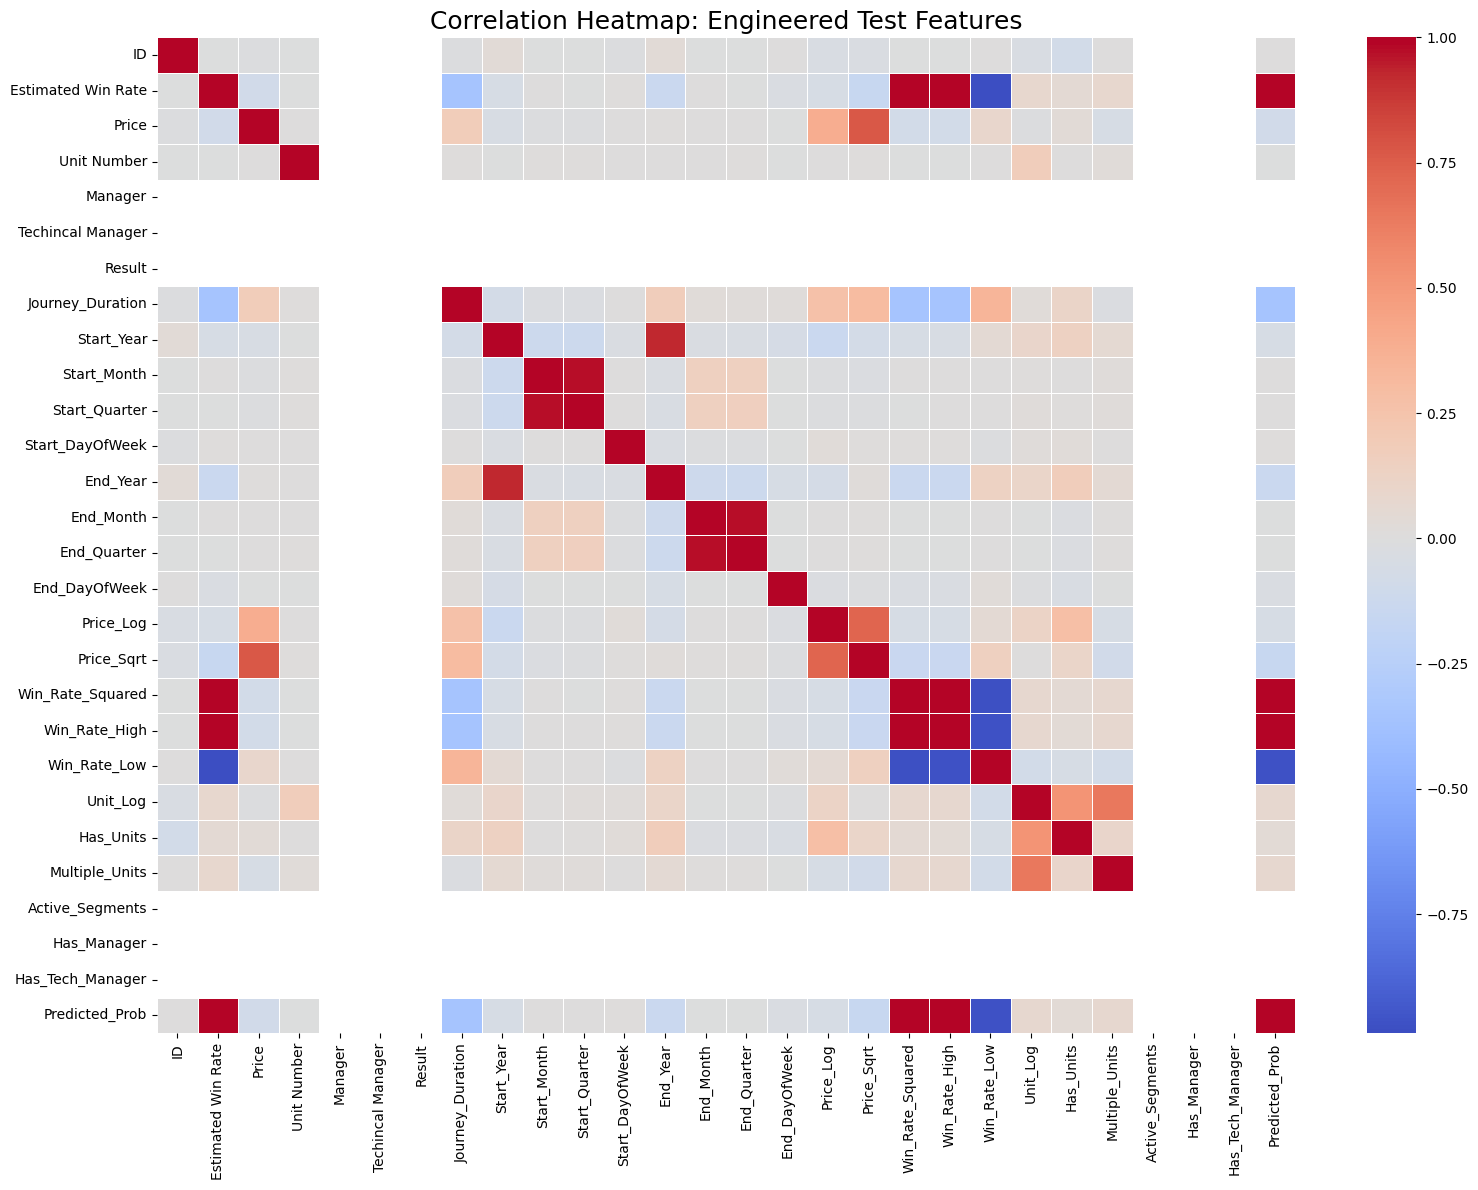

In [142]:

#### Correlation Heatmap of Engineered Test Features

import matplotlib.pyplot as plt
import seaborn as sns

# Select only numeric columns for correlation
numeric_cols = test_featured.select_dtypes(include=['number']).columns
corr_matrix = test_featured[numeric_cols].corr()

plt.figure(figsize=(16, 12))
sns.heatmap(corr_matrix, annot=False, cmap='coolwarm', center=0, linewidths=0.5)
plt.title('Correlation Heatmap: Engineered Test Features', fontsize=18)
plt.tight_layout()
plt.show()


In [ ]:


# Prepare feature matrices
exclude_cols = ['ID', 'Result', 'Customer ID']
feature_cols = [col for col in train_featured.columns if col not in exclude_cols]

X = train_featured[feature_cols].copy()
X_test = test_featured[feature_cols].copy()

# Align columns
common_cols = sorted(list(set(X.columns) & set(X_test.columns)))
X = X[common_cols]
X_test = X_test[common_cols]

print(f"Features selected: {len(common_cols)} common features")

# Encode categorical features
print("\nStep 3: Encoding categorical variables...")
categorical_cols = X.select_dtypes(include=['object']).columns
print(f"Categorical columns to encode: {len(categorical_cols)}")

for col in categorical_cols:
    le = LabelEncoder()
    
    X[col] = X[col].fillna('missing').astype(str)
    X_test[col] = X_test[col].fillna('missing').astype(str)
    
    all_values = pd.concat([X[col], X_test[col]]).unique()
    le.fit(all_values)
    
    X[col] = le.transform(X[col])
    X_test[col] = le.transform(X_test[col])

# Handle remaining missing values
for col in X.columns:
    if X[col].isnull().any():
        median_val = X[col].median()
        X[col] = X[col].fillna(median_val)
        X_test[col] = X_test[col].fillna(median_val)

# Convert to arrays
X = X.values.astype(np.float32)
X_test = X_test.values.astype(np.float32)

print(f"Final shapes - Training: {X.shape}, Test: {X_test.shape}")

# Model training
print("\nStep 4: Training models...")
X_train, X_val, y_train, y_val = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

models = {
    'RandomForest': RandomForestClassifier(
        n_estimators=150, max_depth=12, min_samples_split=15,
        min_samples_leaf=8, max_features='sqrt',
        random_state=42, n_jobs=-1
    ),
    'XGBoost': xgb.XGBClassifier(
        n_estimators=150, max_depth=6, learning_rate=0.08,
        subsample=0.8, colsample_bytree=0.8,
        random_state=42, use_label_encoder=False, eval_metric='logloss'
    ),
    'LightGBM': lgb.LGBMClassifier(
        n_estimators=150, max_depth=6, learning_rate=0.08,
        num_leaves=40, subsample=0.8, colsample_bytree=0.8,
        random_state=42, verbose=-1
    ),
    'GradientBoosting': GradientBoostingClassifier(
        n_estimators=150, max_depth=5, learning_rate=0.08,
        subsample=0.8, max_features='sqrt',
        random_state=42
    )
}

validation_scores = {}
test_probabilities = {}
test_binary = {}

for name, model in models.items():
    print(f"\nTraining {name}...")
    model.fit(X_train, y_train)
    
    # Validation performance
    val_prob = model.predict_proba(X_val)[:, 1]
    val_binary = model.predict(X_val)
    
    auc = roc_auc_score(y_val, val_prob)
    acc = accuracy_score(y_val, val_binary)
    validation_scores[name] = auc
    
    # Test predictions - both probability and binary
    test_prob = model.predict_proba(X_test)[:, 1]
    test_bin = model.predict(X_test)
    
    test_probabilities[name] = test_prob
    test_binary[name] = test_bin
    
    print(f"  Validation AUC: {auc:.4f}")
    print(f"  Validation Accuracy: {acc:.4f}")

# Create ensembles
print("\nStep 5: Creating ensemble predictions...")

# Calculate weights based on AUC scores
total_score = sum(validation_scores.values())
weights = {name: score/total_score for name, score in validation_scores.items()}

print("Model weights based on AUC:")
for name, weight in sorted(weights.items(), key=lambda x: x[1], reverse=True):
    print(f"  {name}: {weight:.3f}")

# Weighted ensemble for probabilities
ensemble_prob = np.zeros(len(X_test))
for name, weight in weights.items():
    ensemble_prob += test_probabilities[name] * weight

# Majority voting for binary predictions
ensemble_binary_votes = np.array(list(test_binary.values()))
ensemble_binary = (ensemble_binary_votes.sum(axis=0) >= len(models)/2).astype(int)

# Retrain on full data for final predictions
print("\nStep 6: Retraining on full dataset...")
final_probabilities = []
final_binary_predictions = []

for name, model in models.items():
    print(f"Retraining {name}...")
    model.fit(X, y)
    
    prob = model.predict_proba(X_test)[:, 1]
    binary = model.predict(X_test)
    
    final_probabilities.append(prob)
    final_binary_predictions.append(binary)

# Final ensembles
final_ensemble_prob = np.mean(final_probabilities, axis=0)
final_ensemble_binary = (np.array(final_binary_predictions).sum(axis=0) >= len(models)/2).astype(int)

# Create submission files
print("\nStep 7: Creating submission files...")

# Submission 1: Probability predictions (for ROC AUC evaluation)
submission_probability = pd.DataFrame({
    'ID': test_featured['ID'].values,
    'TARGET': final_ensemble_prob
})
submission_probability['TARGET'] = submission_probability['TARGET'].clip(0.0001, 0.9999)

# Submission 2: Binary predictions
submission_binary = pd.DataFrame({
    'ID': test_featured['ID'].values,
    'TARGET': final_ensemble_binary
})

# Save both files
submission_probability.to_csv('submission_probability.csv', index=False)
submission_binary.to_csv('submission_binary.csv', index=False)

# Display statistics
print("\n" + "=" * 60)
print("SUBMISSION FILE 1: PROBABILITY PREDICTIONS")
print("File name: submission_probability.csv")
print(f"Shape: {submission_probability.shape}")
print(f"TARGET range: [{submission_probability['TARGET'].min():.4f}, {submission_probability['TARGET'].max():.4f}]")
print(f"TARGET mean: {submission_probability['TARGET'].mean():.4f}")
print(f"TARGET std: {submission_probability['TARGET'].std():.4f}")
print("\nFirst 5 rows:")
print(submission_probability.head())

print("\n" + "=" * 60)
print("SUBMISSION FILE 2: BINARY PREDICTIONS")
print("File name: submission_binary.csv")
print(f"Shape: {submission_binary.shape}")
print(f"Class distribution: 0={sum(submission_binary['TARGET']==0)}, 1={sum(submission_binary['TARGET']==1)}")
print(f"Positive class percentage: {sum(submission_binary['TARGET']==1)/len(submission_binary)*100:.1f}%")
print("\nFirst 5 rows:")
print(submission_binary.head())

# Comparison visualization
plt.figure(figsize=(15, 5))

plt.subplot(1, 3, 1)
plt.hist(submission_probability['TARGET'], bins=50, edgecolor='black', alpha=0.7)
plt.title('Probability Distribution')
plt.xlabel('Predicted Probability')
plt.ylabel('Frequency')

plt.subplot(1, 3, 2)
plt.bar(['Class 0', 'Class 1'], 
        [sum(submission_binary['TARGET']==0), sum(submission_binary['TARGET']==1)],
        color=['coral', 'lightgreen'])
plt.title('Binary Prediction Distribution')
plt.ylabel('Count')

plt.subplot(1, 3, 3)
threshold = 0.5
binary_from_prob = (submission_probability['TARGET'] > threshold).astype(int)
confusion = pd.crosstab(submission_binary['TARGET'], binary_from_prob, 
                        rownames=['Binary Ensemble'], colnames=['Prob > 0.5'])
sns.heatmap(confusion, annot=True, fmt='d', cmap='Blues')
plt.title('Binary vs Probability (>0.5) Agreement')

plt.tight_layout()
plt.show()

print("\n" + "=" * 60)
print("PIPELINE COMPLETED SUCCESSFULLY")
print("\nTwo submission files created:")
print("1. submission_probability.csv - Use this for ROC AUC evaluation")
print("2. submission_binary.csv - Binary classification output")
print("\nThe competition requires probability predictions for ROC AUC scoring.")
print("=" * 60)